=== 🚚 Western Province Distance Matrix (Kilometers) ===
                  Kelaniya (Depot)  Colombo Fort  Nugegoda  Dehiwala  \
Kelaniya (Depot)               0.0          10.7      12.3      16.4   
Colombo Fort                  10.7           0.0      11.1      12.5   
Nugegoda                      12.3          11.1       0.0       4.5   
Dehiwala                      16.4          12.5       4.5       0.0   
Maharagama                    15.4          17.4       6.6       8.8   
Kadawatha                      8.9          18.6      20.8      25.1   
Gampaha                       23.4          32.0      35.4      39.7   
Negombo                       38.6          39.7      49.2      51.9   

                  Maharagama  Kadawatha  Gampaha  Negombo  
Kelaniya (Depot)        15.4        8.9     23.4     38.6  
Colombo Fort            17.4       18.6     32.0     39.7  
Nugegoda                 6.6       20.8     35.4     49.2  
Dehiwala                 8.8       25.1     39.7     51

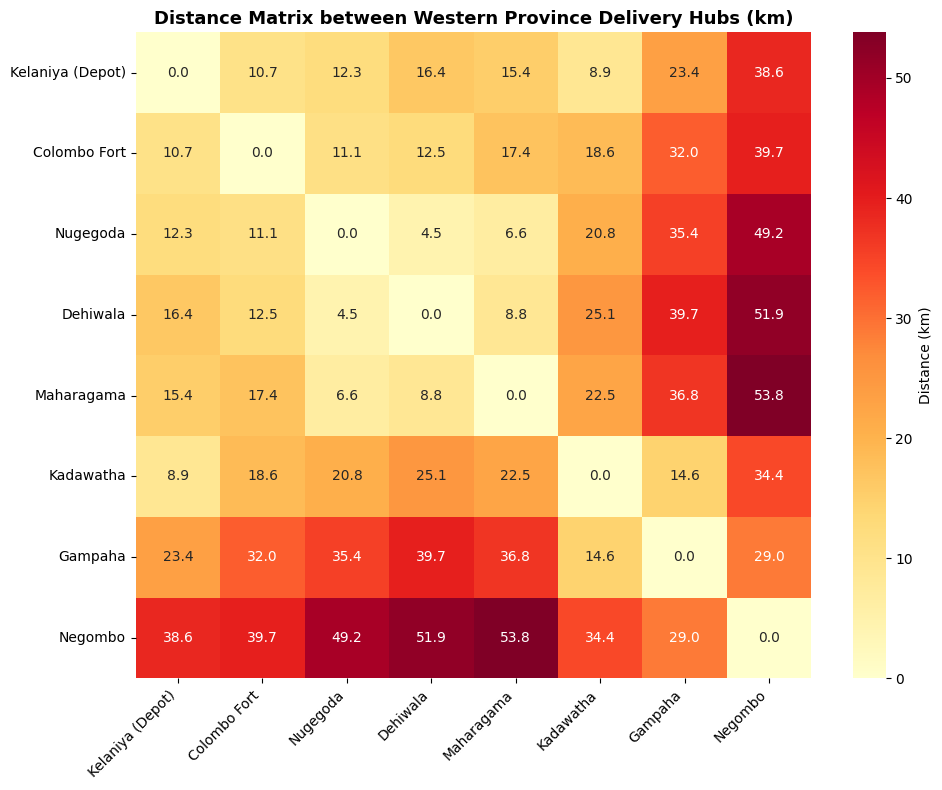

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations

# 1. Define the 8 Western Province Delivery Hubs with real GPS Coordinates (Latitude, Longitude)
hubs = {
    'Kelaniya (Depot)': (6.9538, 79.9147),
    'Colombo Fort':     (6.9344, 79.8428),
    'Nugegoda':         (6.8728, 79.8886),
    'Dehiwala':         (6.8511, 79.8659),
    'Maharagama':       (6.8480, 79.9269),
    'Kadawatha':        (7.0016, 79.9533),
    'Gampaha':          (7.0917, 79.9999),
    'Negombo':          (7.2088, 79.8358)
}

location_names = list(hubs.keys())
coords = list(hubs.values())
num_hubs = len(hubs)

# 2. Haversine function to compute distances between GPS points
def haversine_km(coord1, coord2):
    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371.0 # Earth radius in km
    # Multiply by 1.3 to account for Sri Lankan urban road curvature vs straight-line flight
    return round(c * r * 1.3, 1)

# 3. Construct the Pairwise Distance Matrix (km)
dist_matrix = np.zeros((num_hubs, num_hubs))
for i in range(num_hubs):
    for j in range(num_hubs):
        dist_matrix[i][j] = haversine_km(coords[i], coords[j])

dist_df = pd.DataFrame(dist_matrix, index=location_names, columns=location_names)

print("=== 🚚 Western Province Distance Matrix (Kilometers) ===")
print(dist_df)

# 4. Plot Distance Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dist_df, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Distance (km)'})
plt.title('Distance Matrix between Western Province Delivery Hubs (km)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

             🚚 THE OPTIMAL WESTERN PROVINCE DELIVERY ROUTE               
Optimal Delivery Sequence:
  Start:  Kelaniya (Depot)
  Stop 1: Maharagama
  Stop 2: Nugegoda
  Stop 3: Dehiwala
  Stop 4: Colombo Fort
  Stop 5: Negombo
  Stop 6: Gampaha
  Stop 7: Kadawatha
  Return: Kelaniya (Depot)

--- 📊 Performance & Financial Metrics ---
Naive Route Distance   : 222.2 km (Fuel Cost: Rs. 12,591.33)
Optimal Route Distance : 131.2 km (Fuel Cost: Rs. 7,434.67)
Distance Reduced       : 91.0 km (41.0% reduction)
Daily Fuel Saved (Trip): Rs. 5,156.67
Est. Annual Fleet ROI  : Rs. 15,470,000.00 LKR (10-Truck Fleet)


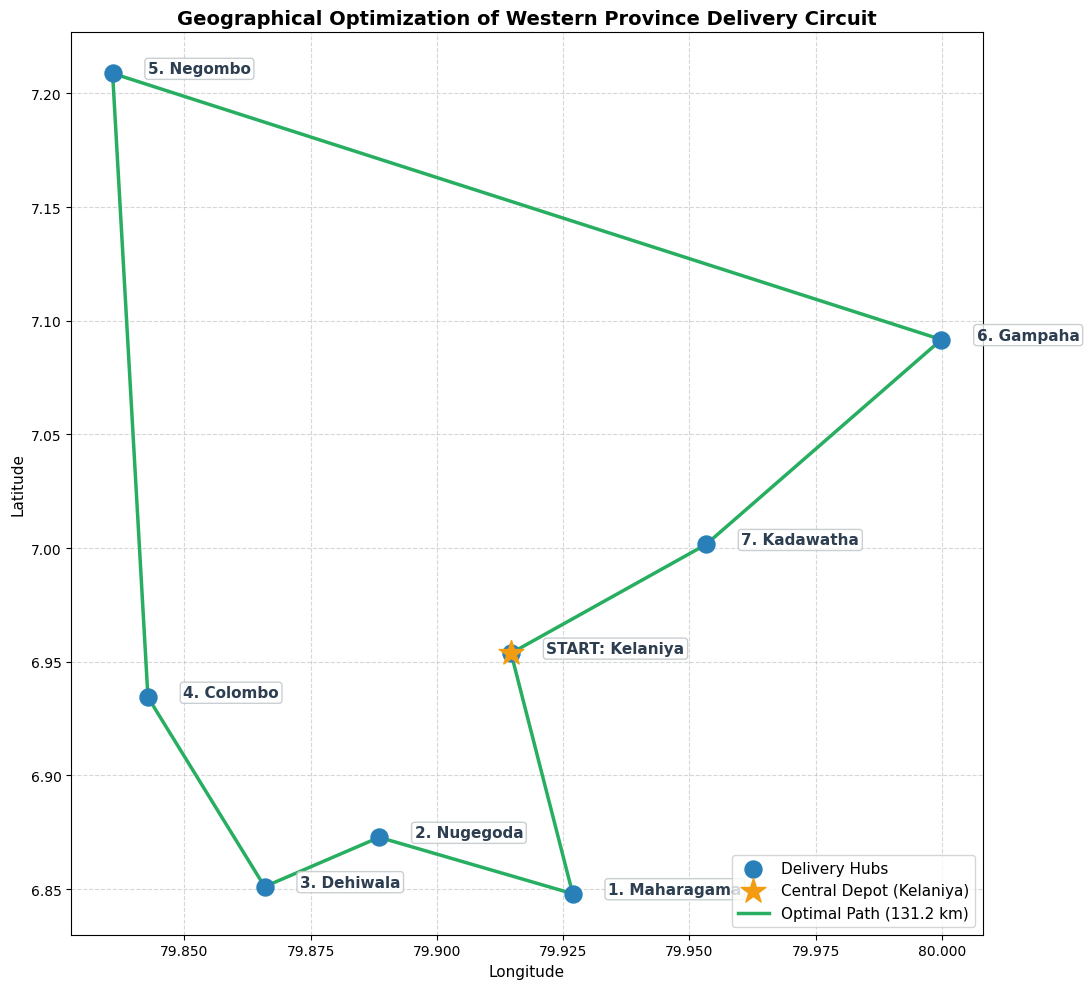

In [3]:
import itertools

# 1. The 7 drop-off destinations (Indices 1 to 7; Depot is Index 0)
destinations = list(range(1, num_hubs))

# 2. Search all 5,040 route permutations to find the global minimum distance
best_distance = float('inf')
best_route = None

for perm in itertools.permutations(destinations):
    # Route starts at Depot (0), visits permutation, and returns to Depot (0)
    current_route = [0] + list(perm) + [0]
    total_dist = sum(dist_matrix[current_route[k]][current_route[k+1]] for k in range(len(current_route)-1))

    if total_dist < best_distance:
        best_distance = total_dist
        best_route = current_route

# 3. Compare with a Naive / Unoptimized route (dispatching randomly as orders arrived)
naive_route = [0, 7, 4, 6, 3, 1, 2, 5, 0] # Random criss-cross order
naive_distance = sum(dist_matrix[naive_route[k]][naive_route[k+1]] for k in range(len(naive_route)-1))

# 4. Calculate Financial Savings (Sri Lankan Corporate Logistics Context)
diesel_price_lkr = 340.0 # LKR per liter
truck_mileage = 6.0      # km per liter in urban delivery traffic

naive_fuel_cost = (naive_distance / truck_mileage) * diesel_price_lkr
optimal_fuel_cost = (best_distance / truck_mileage) * diesel_price_lkr
fuel_saved_per_trip = naive_fuel_cost - optimal_fuel_cost
annual_fleet_savings = fuel_saved_per_trip * 25 * 12 * 10 # 10 trucks, 25 working days/month

print("==========================================================================")
print("             🚚 THE OPTIMAL WESTERN PROVINCE DELIVERY ROUTE               ")
print("==========================================================================")
print("Optimal Delivery Sequence:")
route_names = [location_names[idx] for idx in best_route]
for step, name in enumerate(route_names):
    if step == 0:
        print(f"  Start:  {name}")
    elif step == len(route_names) - 1:
        print(f"  Return: {name}")
    else:
        print(f"  Stop {step}: {name}")

print("\n--- 📊 Performance & Financial Metrics ---")
print(f"Naive Route Distance   : {naive_distance:.1f} km (Fuel Cost: Rs. {naive_fuel_cost:,.2f})")
print(f"Optimal Route Distance : {best_distance:.1f} km (Fuel Cost: Rs. {optimal_fuel_cost:,.2f})")
print(f"Distance Reduced       : {naive_distance - best_distance:.1f} km ({((naive_distance - best_distance)/naive_distance)*100:.1f}% reduction)")
print(f"Daily Fuel Saved (Trip): Rs. {fuel_saved_per_trip:,.2f}")
print(f"Est. Annual Fleet ROI  : Rs. {annual_fleet_savings:,.2f} LKR (10-Truck Fleet)")
print("==========================================================================")

# 5. Plot the Geographical Delivery Route Network
plt.figure(figsize=(11, 10))

# Extract Longitude (X) and Latitude (Y)
lons = [coords[i][1] for i in range(num_hubs)]
lats = [coords[i][0] for i in range(num_hubs)]

# Plot all hubs
plt.scatter(lons, lats, color='#2980B9', s=150, zorder=3, label='Delivery Hubs')
# Highlight the Depot (Kelaniya) as a gold star
plt.scatter(coords[0][1], coords[0][0], color='#F39C12', s=350, marker='*', zorder=4, label='Central Depot (Kelaniya)')

# Draw the optimal route path
route_lons = [coords[i][1] for i in best_route]
route_lats = [coords[i][0] for i in best_route]
plt.plot(route_lons, route_lats, color='#27AE60', linewidth=2.5, linestyle='-', zorder=2, label=f'Optimal Path ({best_distance:.1f} km)')

# Add town labels and sequence numbers
for step, hub_idx in enumerate(best_route[:-1]):
    hub_name = location_names[hub_idx].split(' ')[0] # Short name
    offset = 0.007
    label_text = f"{step}. {hub_name}" if step > 0 else "START: Kelaniya"
    plt.annotate(label_text, (coords[hub_idx][1] + offset, coords[hub_idx][0]),
                 fontsize=11, fontweight='bold', color='#2C3E50',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

plt.title('Geographical Optimization of Western Province Delivery Circuit', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()